# Fault Detection using Machine Learning

This project aims to classify whether a device is operating normally (Class = 0) or is faulty (Class = 1) using 47 numerical features.

Evaluation Metrics:
- Accuracy
- F1 Score

Since the dataset has slight class imbalance (~60-40), F1 Score is prioritized.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [15]:
train = pd.read_csv(r"C:\Users\yuvraj pratap singh\Desktop\ml-hack\data\TRAIN.csv")

print("Shape:", train.shape)
train.head()

Shape: (43776, 48)


,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F39,F40,F41,F42,F43,F44,F45,F46,F47,Class
0,0.185570,0.004568,0.005362,0.003335,0.005415,0.004895,0.012764,0.120138,0.140450,3.361753,...,0.041526,-0.230857,0.003310,0.042250,0.005975,0.002104,0.013878,0.001518,0.011347,0
1,0.369536,0.003983,0.003386,0.004902,0.007570,0.012136,0.118050,0.323925,0.132093,2.766117,...,-0.141285,-6.222857,0.834177,0.227968,0.018463,-0.020487,0.001246,0.007489,0.008724,1
2,0.602510,0.008442,0.012961,0.012870,0.046885,0.115401,0.065688,0.306677,0.498805,4.521201,...,0.011334,10.335251,-0.276614,-0.198900,-0.012756,0.014286,-0.001866,0.002687,0.013452,1
3,0.347957,0.064721,0.013611,0.011541,0.006492,0.008690,0.013192,0.164553,0.298665,3.170847,...,0.190479,2.864912,-1.921939,0.891690,1.108098,0.635431,0.081368,-0.000225,0.009166,0
4,0.233653,0.012217,0.010088,0.022095,0.026040,0.015062,0.016063,0.084648,0.213367,8.150943,...,0.203164,0.001812,-0.092731,0.005280,-0.213985,0.032195,0.002081,0.028930,-0.025912,1


In [16]:
train["Class"].value_counts(normalize=True)

Class
0    0.604555
1    0.395445
Name: proportion, dtype: float64

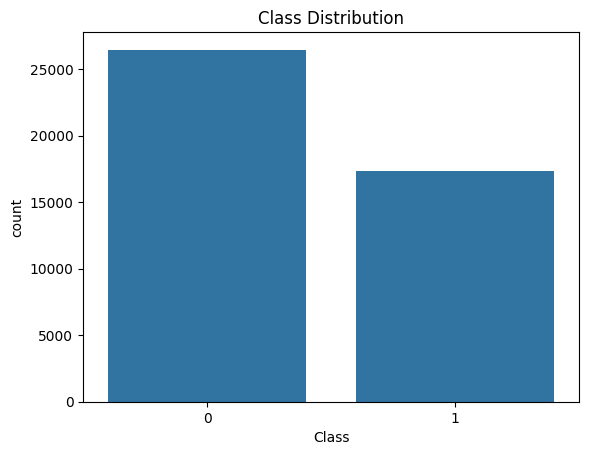

In [17]:
sns.countplot(x="Class", data=train)
plt.title("Class Distribution")
plt.show()

In [18]:
X = train.drop("Class", axis=1)
y = train["Class"]

In [19]:
#startified k-fold validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

StratifiedKFold is used to preserve class distribution across folds,
ensuring reliable F1 score estimation.

In [20]:
#tuned XGBoost 

In [21]:
xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

In [22]:
#out-of-fold evalutaion
oof_probs = np.zeros(len(y))

for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    xgb.fit(X_train, y_train)
    oof_probs[val_idx] = xgb.predict_proba(X_val)[:, 1]

In [23]:
#threshold optimization
best_f1 = 0
best_threshold = 0

for t in np.arange(0.3, 0.7, 0.02):
    preds = (oof_probs > t).astype(int)
    score = f1_score(y, preds)
    
    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best OOF F1:", best_f1)

Best Threshold: 0.4400000000000001
Best OOF F1: 0.9809413131900058


## Final Model Summary

- Model: Tuned XGBoost
- Validation Strategy: Stratified 5-Fold Cross Validation
- Best Threshold: 0.44
- Best OOF F1 Score: ~0.9809

The optimized threshold improves performance over default 0.5.